In [1]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')

Cloning into 'temporalgnn-nids'...
remote: Enumerating objects: 781, done.
remote: Counting objects: 100% (505/505), done.
remote: Compressing objects: 100% (310/310), done.
remote: Total 781 (delta 178), reused 260 (delta 84), pack-reused 276 (from 1)
Receiving objects: 100% (781/781), 4.46 MiB | 14.76 MiB/s, done.
Resolving deltas: 100% (252/252), done.
Mounted at /content/drive


In [2]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.8 MB/s eta 0:00:00


In [3]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import gc

import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

In [4]:
from utils.datasets   import NF_IDS_Dataset
from utils.models     import (
    SimpleMLP,
    EdgeGRU_Baseline_NoX,    EdgeGRU_Baseline_Entropy,
    E_GraphSAGE,             E_GraphSAGE_Entropy,
    StaticGNN_Identity,      StaticGNN_Identity_Entropy,
    ST_GNN_Identity,         ST_GNN_Identity_Entropy,
)
from utils.evaluation import (
    evaluate_test1, evaluate_test2,
    gather_metrics, apply_1sd_rule,
)

# ── Display names ──────────────────────────────────────────────────────────
NAME_MAP = {
    'SimpleMLP_BiasOn':                              'Simple MLP',
    'EGraphSAGE_BiasOn':                             'E-GraphSAGE',
    'EdgeGRU_NoX_BiasOn':                            'Edge GRU',
    'StaticGNN_BiasOn_robust_Identity':              'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone':           'ST-GNN',
    'EGraphSAGE_Entropy_BiasOn':                     'E-GraphSAGE + Entropy',
    'EdgeGRU_BiasOn_entropy':                        'Edge GRU + Entropy',
    'StaticGNN_BiasOn_robust_Identity_entropy':      'Static GNN + Entropy',
    'ST_GNN_BiasOn_robust_Identity_clone_entropy':   'ST-GNN + Entropy',
}

MODEL_ORDER = [
    'Simple MLP',
    'E-GraphSAGE',        'E-GraphSAGE + Entropy',
    'Edge GRU',           'Edge GRU + Entropy',
    'Static GNN',         'Static GNN + Entropy',
    'ST-GNN',             'ST-GNN + Entropy',
]

COLORS = {
    'Simple MLP':               '#95a5a6',
    'E-GraphSAGE':              '#d7bde2',
    'E-GraphSAGE + Entropy':    '#6c3483',
    'Edge GRU':                 '#85c1e9',
    'Edge GRU + Entropy':       '#1a5276',
    'Static GNN':               '#f0b27a',
    'Static GNN + Entropy':     '#7d3c00',
    'ST-GNN':                   '#82e0aa',
    'ST-GNN + Entropy':         '#1e8449',
}


In [5]:
# ── Shared hyperparameters (same for all 7 models) ─────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NODE_DIM   = 16
EDGE_DIM   = 32
HIDDEN_DIM = 32
DROPOUT    = 0.2
BIAS_VALUE = -2.9968

model_config = {
    'model_name': None,
    'type': None,
    'model_params': {
        'node_dim':          NODE_DIM,
        'edge_dim':          EDGE_DIM,
        'hidden_dim':        HIDDEN_DIM,
        'dropout':           DROPOUT,
        'output_bias_init':  BIAS_VALUE,
    },
    'extra_params': {
        'epochs':        60,
        'batch_steps':   10,
        'pos_weight':    2.0,
        'learning_rate': 0.005,
    }
}

# ── Results directories ────────────────────────────────────────────────────
DIR_NOENT = './results_earlystopping'
DIR_ENT   = './results_earlystopping_entropy'
PLOTS_DIR = './results_comparison/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Device: {DEVICE}')

Device: cpu


# Test 1 — All Seeds (Mean ± Std)

In [6]:
# ── Datasets ───────────────────────────────────────────────────────────────
test1_noent = NF_IDS_Dataset(root_dir='./dataset_processed',         split='test')
test1_ent   = NF_IDS_Dataset(root_dir='./dataset_processed_entropy', split='test')

loader_t1_noent = DataLoader(test1_noent, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True)
loader_t1_ent   = DataLoader(test1_ent,   batch_size=1, shuffle=False, num_workers=2, persistent_workers=True)

print(f'Test1 noentropy: {len(test1_noent)} snapshots')
print(f'Test1 entropy:   {len(test1_ent)} snapshots')

Test1 noentropy: 429 snapshots
Test1 entropy:   429 snapshots


In [7]:
# ── Evaluate all 9 experiments on Test 1 ──────────────────────────────────
T1_DIRNAME = 'test1_results'

# Noentropy
df_t1_mlp     = evaluate_test1(SimpleMLP,            model_config, loader_t1_noent, 'SimpleMLP_BiasOn',                    DEVICE, DIR_NOENT, T1_DIRNAME)
df_t1_esage   = evaluate_test1(E_GraphSAGE,           model_config, loader_t1_noent, 'EGraphSAGE_BiasOn',                   DEVICE, DIR_NOENT, T1_DIRNAME)
df_t1_egru    = evaluate_test1(EdgeGRU_Baseline_NoX,  model_config, loader_t1_noent, 'EdgeGRU_NoX_BiasOn',                  DEVICE, DIR_NOENT, T1_DIRNAME)
df_t1_sgnn    = evaluate_test1(StaticGNN_Identity,    model_config, loader_t1_noent, 'StaticGNN_BiasOn_robust_Identity',    DEVICE, DIR_NOENT, T1_DIRNAME)
df_t1_stgnn   = evaluate_test1(ST_GNN_Identity,       model_config, loader_t1_noent, 'ST_GNN_BiasOn_robust_Identity_clone', DEVICE, DIR_NOENT, T1_DIRNAME)

# Entropy
df_t1_esagee  = evaluate_test1(E_GraphSAGE_Entropy,       model_config, loader_t1_ent, 'EGraphSAGE_Entropy_BiasOn',                      DEVICE, DIR_ENT, T1_DIRNAME)
df_t1_egrue   = evaluate_test1(EdgeGRU_Baseline_Entropy,  model_config, loader_t1_ent, 'EdgeGRU_BiasOn_entropy',                          DEVICE, DIR_ENT, T1_DIRNAME)
df_t1_sgnne   = evaluate_test1(StaticGNN_Identity_Entropy,model_config, loader_t1_ent, 'StaticGNN_BiasOn_robust_Identity_entropy',        DEVICE, DIR_ENT, T1_DIRNAME)
df_t1_stgnne  = evaluate_test1(ST_GNN_Identity_Entropy,   model_config, loader_t1_ent, 'ST_GNN_BiasOn_robust_Identity_clone_entropy',     DEVICE, DIR_ENT, T1_DIRNAME)


  Skipping inference — loaded from cache: ./results_earlystopping/test1_results/test1_metrics_SimpleMLP_BiasOn.csv
  Skipping inference — loaded from cache: ./results_earlystopping/test1_results/test1_metrics_EdgeGRU_BiasOn.csv
  Skipping inference — loaded from cache: ./results_earlystopping/test1_results/test1_metrics_StaticGNN_BiasOn_robust_Identity.csv
  Skipping inference — loaded from cache: ./results_earlystopping/test1_results/test1_metrics_ST_GNN_BiasOn_robust_Identity_clone.csv


In [9]:
# ── Combine and label ──────────────────────────────────────────────────────
label_map = {
    id(df_t1_mlp):    ('Simple MLP',             'noentropy'),
    id(df_t1_esage):  ('E-GraphSAGE',            'noentropy'),
    id(df_t1_egru):   ('Edge GRU',               'noentropy'),
    id(df_t1_sgnn):   ('Static GNN',             'noentropy'),
    id(df_t1_stgnn):  ('ST-GNN',                 'noentropy'),
    id(df_t1_esagee): ('E-GraphSAGE + Entropy',  'entropy'),
    id(df_t1_egrue):  ('Edge GRU + Entropy',      'entropy'),
    id(df_t1_sgnne):  ('Static GNN + Entropy',    'entropy'),
    id(df_t1_stgnne): ('ST-GNN + Entropy',        'entropy'),
}

dfs = [df_t1_mlp, df_t1_esage, df_t1_egru, df_t1_sgnn, df_t1_stgnn,
       df_t1_esagee, df_t1_egrue, df_t1_sgnne, df_t1_stgnne]

for df in dfs:
    model_name, variant = label_map[id(df)]
    df['model']   = model_name
    df['variant'] = variant

df_test1 = pd.concat(dfs, ignore_index=True)
df_test1['model'] = pd.Categorical(df_test1['model'], categories=MODEL_ORDER, ordered=True)
print(f'Total rows: {len(df_test1)}  ({df_test1["model"].nunique()} models × ~5 seeds)')


Total rows: 35  (7 models × ~5 seeds)


In [10]:
# ── Summary table: mean ± std per model ───────────────────────────────────
METRICS = ['Precision', 'Recall', 'F1', 'F2', 'AUC-PR', 'AUC-ROC', 'FPR']
available = [m for m in METRICS if m in df_test1.columns]

rows = []
for model in MODEL_ORDER:
    sub = df_test1[df_test1['model'] == model]
    if sub.empty:
        continue
    row = {'Model': model}
    for m in available:
        mu  = sub[m].mean()
        std = sub[m].std()
        row[m] = f'{mu:.3f} ± {std:.3f}'
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Model')
print('\nTest 1 — Mean ± Std across 5 seeds')
print('=' * 90)
display(df_summary)


Test 1 — Mean ± Std across 5 seeds


,Precision,Recall,F1,F2,AUC-PR,AUC-ROC,FPR
Model,,,,,,,
Simple MLP,0.004 ± 0.004,0.001 ± 0.001,0.001 ± 0.002,0.001 ± 0.001,0.051 ± 0.008,0.822 ± 0.019,0.002 ± 0.002
Edge GRU,0.103 ± 0.029,0.495 ± 0.191,0.162 ± 0.031,0.261 ± 0.055,0.094 ± 0.015,0.874 ± 0.010,0.087 ± 0.044
Edge GRU + Entropy,0.388 ± 0.226,0.680 ± 0.201,0.467 ± 0.173,0.565 ± 0.167,0.500 ± 0.229,0.963 ± 0.022,0.026 ± 0.014
Static GNN,0.493 ± 0.105,0.694 ± 0.051,0.567 ± 0.072,0.633 ± 0.034,0.426 ± 0.042,0.932 ± 0.007,0.015 ± 0.009
Static GNN + Entropy,0.457 ± 0.099,0.716 ± 0.036,0.551 ± 0.071,0.635 ± 0.030,0.407 ± 0.087,0.933 ± 0.004,0.017 ± 0.009
ST-GNN,0.691 ± 0.062,0.728 ± 0.079,0.704 ± 0.032,0.717 ± 0.058,0.671 ± 0.016,0.960 ± 0.006,0.006 ± 0.002
ST-GNN + Entropy,0.555 ± 0.102,0.771 ± 0.033,0.642 ± 0.078,0.713 ± 0.054,0.615 ± 0.130,0.940 ± 0.027,0.012 ± 0.004


In [11]:
# ── Delta table: entropy vs noentropy head-to-head ─────────────────────────
DELTA_METRICS = ['F1', 'AUC-PR', 'Recall', 'FPR']
dm_avail = [m for m in DELTA_METRICS if m in df_test1.columns]

means = df_test1.groupby('model', observed=True)[dm_avail].mean()

arch_pairs = [
    ('E-GraphSAGE', 'E-GraphSAGE + Entropy'),
    ('Edge GRU',    'Edge GRU + Entropy'),
    ('Static GNN',  'Static GNN + Entropy'),
    ('ST-GNN',      'ST-GNN + Entropy'),
]

delta_rows = []
for noent, ent in arch_pairs:
    if noent not in means.index or ent not in means.index:
        continue
    row = {'Architecture': noent}
    for m in dm_avail:
        v0 = means.loc[noent, m]
        v1 = means.loc[ent,   m]
        d  = v1 - v0
        row[f'{m} (no-ent)'] = f'{v0:.3f}'
        row[f'{m} (ent)']    = f'{v1:.3f}'
        sign = '+' if d >= 0 else ''
        row[f'Δ{m}']         = f'{sign}{d:.3f}'
    delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows).set_index('Architecture')
print('\nEntropy impact by architecture (positive Δ = entropy helps)')
print('=' * 90)
display(df_delta)


Entropy impact by architecture (positive Δ = entropy helps)


,F1 (no-ent),F1 (ent),ΔF1,AUC-PR (no-ent),AUC-PR (ent),ΔAUC-PR,Recall (no-ent),Recall (ent),ΔRecall,FPR (no-ent),FPR (ent),ΔFPR
Architecture,,,,,,,,,,,,
Edge GRU,0.162,0.467,+0.305,0.094,0.500,+0.406,0.495,0.680,+0.185,0.087,0.026,-0.062
Static GNN,0.567,0.551,-0.017,0.426,0.407,-0.018,0.694,0.716,+0.022,0.015,0.017,+0.002
ST-GNN,0.704,0.642,-0.062,0.671,0.615,-0.056,0.728,0.771,+0.042,0.006,0.012,+0.006


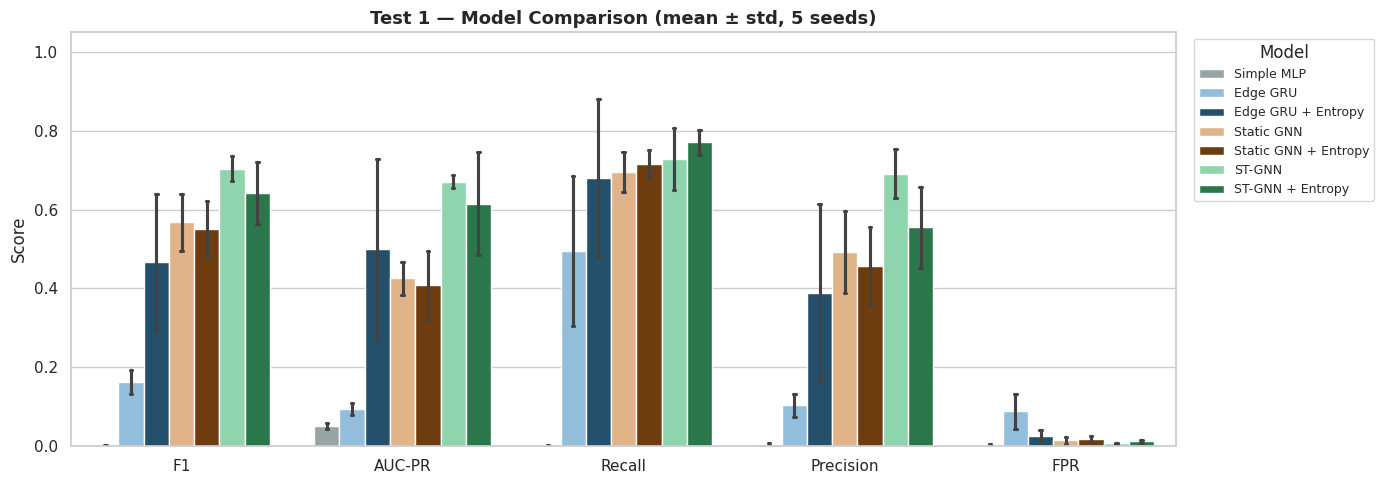

In [12]:
# ── Grouped bar chart: all 7 models × main metrics ────────────────────────
PLOT_METRICS = ['F1', 'AUC-PR', 'Recall', 'Precision', 'FPR']
pm_avail = [m for m in PLOT_METRICS if m in df_test1.columns]

df_melt = df_test1.melt(
    id_vars=['model'], value_vars=pm_avail,
    var_name='Metric', value_name='Value'
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(
    data=df_melt, x='Metric', y='Value', hue='model',
    hue_order=MODEL_ORDER,
    palette=COLORS,
    errorbar='sd', capsize=0.08,
    ax=ax
)
ax.set_title('Test 1 — Model Comparison (mean ± std, 5 seeds)', fontsize=13, weight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/test1_comparison_barplot.png', dpi=300)
plt.show()

/tmp/ipykernel_12458/474834201.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fpr['model'], rotation=30, ha='right', fontsize=9)


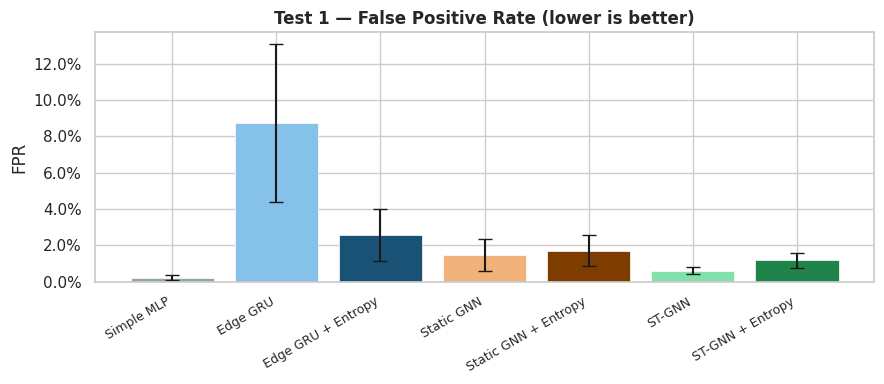

In [13]:
# ── FPR focused chart ─────────────────────────────────────────────────────
if 'FPR' in df_test1.columns:
    df_fpr = df_test1.groupby('model', observed=True)['FPR'].agg(['mean', 'std']).reset_index()
    df_fpr['model'] = pd.Categorical(df_fpr['model'], categories=MODEL_ORDER, ordered=True)
    df_fpr = df_fpr.sort_values('model')

    fig, ax = plt.subplots(figsize=(9, 4))
    colors_list = [COLORS[m] for m in df_fpr['model']]
    bars = ax.bar(df_fpr['model'], df_fpr['mean'], yerr=df_fpr['std'],
                  color=colors_list, capsize=5, edgecolor='white', linewidth=0.5)
    ax.set_title('Test 1 — False Positive Rate (lower is better)', fontsize=12, weight='bold')
    ax.set_ylabel('FPR')
    ax.set_xlabel('')
    ax.set_xticklabels(df_fpr['model'], rotation=30, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/test1_fpr_comparison.png', dpi=300)
    plt.show()

# Test 2 — Champions only (1-SD Rule)

In [14]:
# ── Datasets ───────────────────────────────────────────────────────────────
test2_noent = NF_IDS_Dataset(root_dir='./dataset_processed_thu0103',         split='test2')
test2_ent   = NF_IDS_Dataset(root_dir='./dataset_processed_thu0103_entropy', split='test2')

loader_t2_noent = DataLoader(test2_noent, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True)
loader_t2_ent   = DataLoader(test2_ent,   batch_size=1, shuffle=False, num_workers=2, persistent_workers=True)

print(f'Test2 noentropy: {len(test2_noent)} snapshots')
print(f'Test2 entropy:   {len(test2_ent)} snapshots')

Test2 noentropy: 2822 snapshots
Test2 entropy:   2822 snapshots


In [15]:
# ── Select champions via 1-SD rule (separately per variant) ───────────────
NAME_MAP_NOENT = {k: v for k, v in NAME_MAP.items() if 'entropy' not in k}
NAME_MAP_ENT   = {k: v for k, v in NAME_MAP.items() if 'entropy' in k}

print('── Noentropy ──')
df_metrics_noent = gather_metrics(os.path.join(DIR_NOENT, 'logs'), NAME_MAP_NOENT)
df_champ_noent   = apply_1sd_rule(df_metrics_noent)

print('\n── Entropy ──')
df_metrics_ent   = gather_metrics(os.path.join(DIR_ENT, 'logs'), NAME_MAP_ENT)
df_champ_ent     = apply_1sd_rule(df_metrics_ent)

── Noentropy ──
                       SELECTION OF CHAMPIONS (RULE 1-SD)                       

Architecture: SIMPLE MLP (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.2680 | Std = 0.0223
  -> Zone 1-SD  : Models with F1 >= 0.2457
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 777 | F1: 0.2680 | Training epochs: 59

Architecture: EDGE GRU (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.3465 | Std = 0.0457
  -> Zone 1-SD  : Models with F1 >= 0.3008
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.3071 | Training epochs: 31

Architecture: STATIC GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.4905 | Std = 0.1003
  -> Zone 1-SD  : Models with F1 >= 0.3903
  -> Candidates : 4 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.4905 | Training epochs: 52

Architecture: ST-GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.7727 | Std = 0.0183
  -> Zone 1-SD  : Models with F1 >= 0.7544
  -> Candidates : 3 seed(s) ente

In [16]:
# ── Evaluate champions on Test 2 ──────────────────────────────────────────
T2_DIRNAME = 'test2_results'

noent_pairs = [
    (SimpleMLP,           'SimpleMLP_BiasOn'),
    (E_GraphSAGE,         'EGraphSAGE_BiasOn'),
    (EdgeGRU_Baseline_NoX,'EdgeGRU_NoX_BiasOn'),
    (StaticGNN_Identity,  'StaticGNN_BiasOn_robust_Identity'),
    (ST_GNN_Identity,     'ST_GNN_BiasOn_robust_Identity_clone'),
]

ent_pairs = [
    (E_GraphSAGE_Entropy,         'EGraphSAGE_Entropy_BiasOn'),
    (EdgeGRU_Baseline_Entropy,    'EdgeGRU_BiasOn_entropy'),
    (StaticGNN_Identity_Entropy,  'StaticGNN_BiasOn_robust_Identity_entropy'),
    (ST_GNN_Identity_Entropy,     'ST_GNN_BiasOn_robust_Identity_clone_entropy'),
]

dfs_t2_noent = []



Evaluating: SimpleMLP_BiasOn_seed777
 Precision: 0.8805 | Recall: 0.3226 | F1: 0.4722 | F2: 0.3694 | AUC-PR: 0.3961 | AUC-ROC: 0.8112 | FPR: 0.0022

------------------------------------------------------------

Evaluating: EdgeGRU_BiasOn_seed42
 Precision: 0.3798 | Recall: 0.3952 | F1: 0.3873 | F2: 0.3920 | AUC-PR: 0.4297 | AUC-ROC: 0.8372 | FPR: 0.0330

------------------------------------------------------------

Evaluating: StaticGNN_BiasOn_robust_Identity_seed42
 Precision: 0.5094 | Recall: 0.2071 | F1: 0.2944 | F2: 0.2349 | AUC-PR: 0.3142 | AUC-ROC: 0.8355 | FPR: 0.0102

------------------------------------------------------------

Evaluating: ST_GNN_BiasOn_robust_Identity_clone_seed42
 Precision: 0.6336 | Recall: 0.9419 | F1: 0.7576 | F2: 0.8584 | AUC-PR: 0.8384 | AUC-ROC: 0.9830 | FPR: 0.0278

------------------------------------------------------------

Evaluating: EdgeGRU_BiasOn_entropy_seed99
 Precision: 0.5338 | Recall: 0.6049 | F1: 0.5671 | F2: 0.5892 | AUC-PR: 0.5136 | AU

In [17]:
# ── Combine champion results ───────────────────────────────────────────────
name_map_by_exp = {
    'SimpleMLP_BiasOn':                              'Simple MLP',
    'EGraphSAGE_BiasOn':                             'E-GraphSAGE',
    'EdgeGRU_NoX_BiasOn':                            'Edge GRU',
    'StaticGNN_BiasOn_robust_Identity':              'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone':           'ST-GNN',
    'EGraphSAGE_Entropy_BiasOn':                     'E-GraphSAGE + Entropy',
    'EdgeGRU_BiasOn_entropy':                        'Edge GRU + Entropy',
    'StaticGNN_BiasOn_robust_Identity_entropy':      'Static GNN + Entropy',
    'ST_GNN_BiasOn_robust_Identity_clone_entropy':   'ST-GNN + Entropy',
}

def label_df(df, variant):
    df = df.copy()
    # model_name column has format like 'EdgeGRU_BiasOn_seed42' — strip seed suffix
    df['exp_name'] = df['model_name'].str.replace(r'_seed\d+$', '', regex=True)
    df['model']    = df['exp_name'].map(name_map_by_exp).fillna(df['exp_name'])
    df['variant']  = variant
    return df

dfs_t2_labeled = (
    [label_df(d, 'noentropy') for d in dfs_t2_noent] +
    [label_df(d, 'entropy')   for d in dfs_t2_ent]
)

df_test2 = pd.concat(dfs_t2_labeled, ignore_index=True)
df_test2['model'] = pd.Categorical(df_test2['model'], categories=MODEL_ORDER, ordered=True)
print(f'Champions evaluated: {df_test2["model"].nunique()} models')

Champions evaluated: 7 models


In [18]:
# ── Champions summary table ────────────────────────────────────────────────
T2_METRICS = ['Precision', 'Recall', 'F1', 'F2', 'AUC-PR', 'AUC-ROC', 'FPR']
t2_avail = [m for m in T2_METRICS if m in df_test2.columns]

champ_rows = []
for model in MODEL_ORDER:
    sub = df_test2[df_test2['model'] == model]
    if sub.empty:
        continue
    row = {'Model': model}
    if 'seed' in sub.columns:
        row['Seed'] = int(sub['seed'].iloc[0])
    if 'Best_Epoch' in sub.columns:
        row['Best Epoch'] = int(sub['Best_Epoch'].iloc[0])
    for m in t2_avail:
        row[m] = f'{sub[m].iloc[0]:.3f}'
    champ_rows.append(row)

df_champ_summary = pd.DataFrame(champ_rows).set_index('Model')
print('\nTest 2 — Champion per architecture (1-SD Rule)')
print('=' * 90)
display(df_champ_summary)


Test 2 — Champion per architecture (1-SD Rule)


,Seed,Precision,Recall,F1,F2,AUC-PR,AUC-ROC,FPR
Model,,,,,,,,
Simple MLP,777,0.880,0.323,0.472,0.369,0.396,0.811,0.002
Edge GRU,42,0.380,0.395,0.387,0.392,0.430,0.837,0.033
Edge GRU + Entropy,99,0.534,0.605,0.567,0.589,0.514,0.959,0.027
Static GNN,42,0.509,0.207,0.294,0.235,0.314,0.836,0.010
Static GNN + Entropy,2024,0.690,0.345,0.460,0.383,0.504,0.890,0.008
ST-GNN,42,0.634,0.942,0.758,0.858,0.838,0.983,0.028
ST-GNN + Entropy,42,0.585,0.949,0.724,0.844,0.729,0.978,0.034


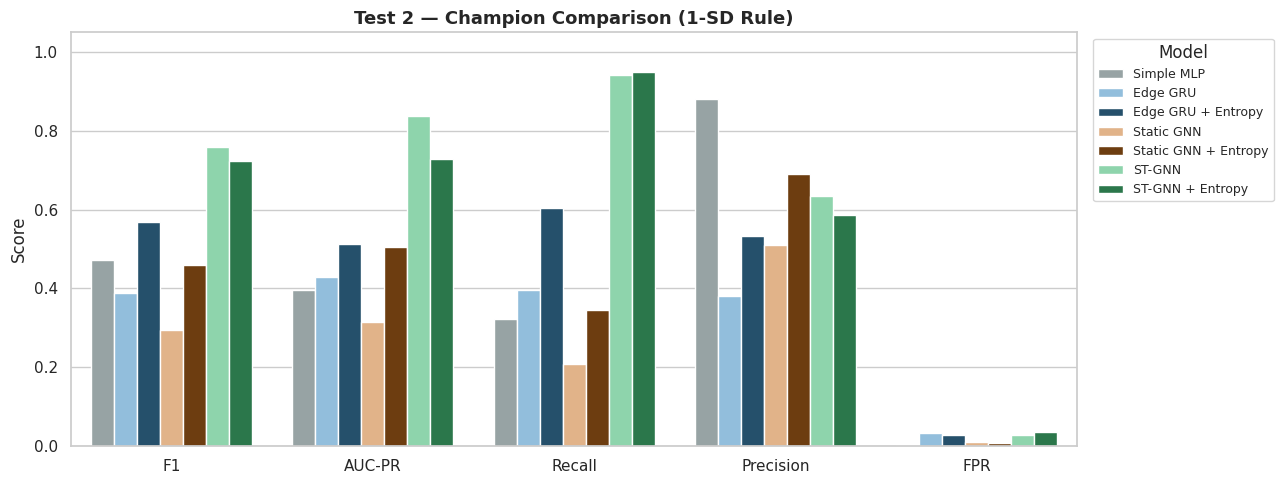

In [19]:
# ── Champions bar chart ────────────────────────────────────────────────────
T2_PLOT_METRICS = ['F1', 'AUC-PR', 'Recall', 'Precision', 'FPR']
t2pm_avail = [m for m in T2_PLOT_METRICS if m in df_test2.columns]

# Convert string columns back to float for plotting
df_test2_plot = df_test2.copy()
for m in t2pm_avail:
    df_test2_plot[m] = pd.to_numeric(df_test2_plot[m], errors='coerce')

df_melt2 = df_test2_plot.melt(
    id_vars=['model'], value_vars=t2pm_avail,
    var_name='Metric', value_name='Value'
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=df_melt2, x='Metric', y='Value', hue='model',
    hue_order=[m for m in MODEL_ORDER if m in df_test2['model'].values],
    palette=COLORS,
    errorbar=None,
    ax=ax
)
ax.set_title('Test 2 — Champion Comparison (1-SD Rule)', fontsize=13, weight='bold')
ax.set_ylim(0, 1.05)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/test2_champions_barplot.png', dpi=300)
plt.show()

# Section 3 — Precision-Recall Curves & Inference Latency

In [20]:
# ── Hardware info (report this in the paper) ──────────────────────────────
import subprocess, platform

print('=== GPU ===')
try:
    print(subprocess.check_output('nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader',
                                   shell=True).decode().strip())
except:
    print('No GPU found.')

print('\n=== CPU ===')
try:
    cpu = subprocess.check_output("grep 'model name' /proc/cpuinfo | head -1", shell=True).decode().strip()
    print(cpu)
except:
    print(platform.processor())

print(f'\nPyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

=== GPU ===
No GPU found.

=== CPU ===
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz

PyTorch: 2.10.0+cpu
CUDA available: False


In [21]:
# ── Load champion helper (same logic as mitre_comparison) ─────────────────
from utils.evaluation import gather_metrics, apply_1sd_rule
from utils.training   import evaluate as eval_model
from sklearn.metrics  import precision_recall_curve, auc
import time

def load_champion(model_class, experiment_name, df_champions, results_dir, device):
    champ = df_champions[df_champions['Raw_Dir_Name'] == experiment_name]
    seed  = int(champ['Seed'].iloc[0])

    npz       = np.load(f'{results_dir}/logs/{experiment_name}/thresholds_{experiment_name}.npz')
    threshold = float(npz[f'seed_{seed}'])

    csv_files = (glob.glob(f'{results_dir}/logs/{experiment_name}/run_metrics_{experiment_name}.csv') or
                 glob.glob(f'{results_dir}/logs/{experiment_name}/metrics_newth_{experiment_name}.csv'))
    df_csv    = pd.read_csv(csv_files[0])
    df_csv.columns = df_csv.columns.str.lower()
    run_id    = df_csv[df_csv['model_name'].str.contains(f'seed{seed}')]['run_id'].iloc[0]

    pth = glob.glob(f'{results_dir}/saved_models/{experiment_name}/{run_id}_*.pth')[0]
    model = model_class(**model_config['model_params']).to(device)
    model.load_state_dict(torch.load(pth, map_location=device))
    model.eval()
    print(f'  {experiment_name} | seed={seed} | threshold={threshold:.6f}')
    return model, threshold, seed

In [23]:
# ── Inference: collect y_probs + measure latency for all 7 models ─────────
# Results stored as: {display_name: {'y_true', 'y_probs', 'threshold', 'mean_ms', 'std_ms', 'n_snapshots'}}
pr_results = {}

MODELS_TO_RUN = [
    # (display_name,            model_class,                 exp_name,                                       results_dir, loader,          is_temporal)
    ('Simple MLP',              SimpleMLP,                   'SimpleMLP_BiasOn',                             DIR_NOENT,   loader_t1_noent, False),
    ('E-GraphSAGE',             E_GraphSAGE,                 'EGraphSAGE_BiasOn',                            DIR_NOENT,   loader_t1_noent, False),
    ('Edge GRU',                EdgeGRU_Baseline_NoX,        'EdgeGRU_NoX_BiasOn',                           DIR_NOENT,   loader_t1_noent, True),
    ('Static GNN',              StaticGNN_Identity,          'StaticGNN_BiasOn_robust_Identity',             DIR_NOENT,   loader_t1_noent, False),
    ('ST-GNN',                  ST_GNN_Identity,             'ST_GNN_BiasOn_robust_Identity_clone',          DIR_NOENT,   loader_t1_noent, True),
    ('E-GraphSAGE + Entropy',   E_GraphSAGE_Entropy,         'EGraphSAGE_Entropy_BiasOn',                    DIR_ENT,     loader_t1_ent,   False),
    ('Edge GRU + Entropy',      EdgeGRU_Baseline_Entropy,    'EdgeGRU_BiasOn_entropy',                       DIR_ENT,     loader_t1_ent,   True),
    ('Static GNN + Entropy',    StaticGNN_Identity_Entropy,  'StaticGNN_BiasOn_robust_Identity_entropy',     DIR_ENT,     loader_t1_ent,   False),
    ('ST-GNN + Entropy',        ST_GNN_Identity_Entropy,     'ST_GNN_BiasOn_robust_Identity_clone_entropy',  DIR_ENT,     loader_t1_ent,   True),
]

# Re-run champion selection (needed for load_champion)
NAME_MAP_NOENT_PR = {k: v for k, v in NAME_MAP.items() if 'entropy' not in k.lower()}
NAME_MAP_ENT_PR   = {k: v for k, v in NAME_MAP.items() if 'entropy'     in k.lower()}
df_champ_noent_pr = apply_1sd_rule(gather_metrics(os.path.join(DIR_NOENT, 'logs'), NAME_MAP_NOENT_PR))
df_champ_ent_pr   = apply_1sd_rule(gather_metrics(os.path.join(DIR_ENT,   'logs'), NAME_MAP_ENT_PR))

for display, mclass, exp_name, results_dir, loader, is_temporal in MODELS_TO_RUN:
    print(f'\n── {display} ──')
    df_champ = df_champ_noent_pr if results_dir == DIR_NOENT else df_champ_ent_pr
    model, threshold, _ = load_champion(mclass, exp_name, df_champ, results_dir, DEVICE)

    pos_weight = torch.tensor([model_config['extra_params']['pos_weight']]).to(DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Latency: timed forward pass over all test1 snapshots ---
    use_stats   = getattr(model, 'use_node_stats', False)
    snap_times  = []
    all_y_true  = []
    all_y_probs = []

    if hasattr(model, 'reset_memory'):
        model.reset_memory()

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            if batch.x.shape[0] == 0:
                continue

            t0 = time.perf_counter()
            if is_temporal:
                out = model(batch.x, batch.edge_index, batch.edge_attr,
                            batch.global_node_ids,
                            *([batch.node_stats] if use_stats else []))
            else:
                out = model(batch.x, batch.edge_index, batch.edge_attr,
                            *([batch.node_stats] if use_stats else []))
            snap_times.append((time.perf_counter() - t0) * 1000)

            probs = torch.sigmoid(out.view(-1)).cpu().numpy()
            all_y_probs.extend(probs.tolist())
            all_y_true.extend(batch.y.cpu().numpy().tolist())

    mean_ms = float(np.mean(snap_times))
    std_ms  = float(np.std(snap_times))
    print(f'  Latency: {mean_ms:.2f} ± {std_ms:.2f} ms/snapshot  (n={len(snap_times)} snapshots)')

    pr_results[display] = {
        'y_true':          np.array(all_y_true),
        'y_probs':         np.array(all_y_probs),
        'threshold':       threshold,
        'mean_ms':         mean_ms,
        'std_ms':          std_ms,
        'n_snapshots':     len(snap_times),
    }

    del model; gc.collect(); torch.cuda.empty_cache()

print('\nAll models done.')

                       SELECTION OF CHAMPIONS (RULE 1-SD)                       

Architecture: SIMPLE MLP (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.2680 | Std = 0.0223
  -> Zone 1-SD  : Models with F1 >= 0.2457
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 777 | F1: 0.2680 | Training epochs: 59

Architecture: EDGE GRU (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.3465 | Std = 0.0457
  -> Zone 1-SD  : Models with F1 >= 0.3008
  -> Candidates : 2 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.3071 | Training epochs: 31

Architecture: STATIC GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.4905 | Std = 0.1003
  -> Zone 1-SD  : Models with F1 >= 0.3903
  -> Candidates : 4 seed(s) entered the safe zone.
     CHAMPION   : Seed 42 | F1: 0.4905 | Training epochs: 52

Architecture: ST-GNN (Seeds analyzed: 5)
  -> F1 Range   : Max = 0.7727 | Std = 0.0183
  -> Zone 1-SD  : Models with F1 >= 0.7544
  -> Candidates : 3 seed(s) entered the safe zon

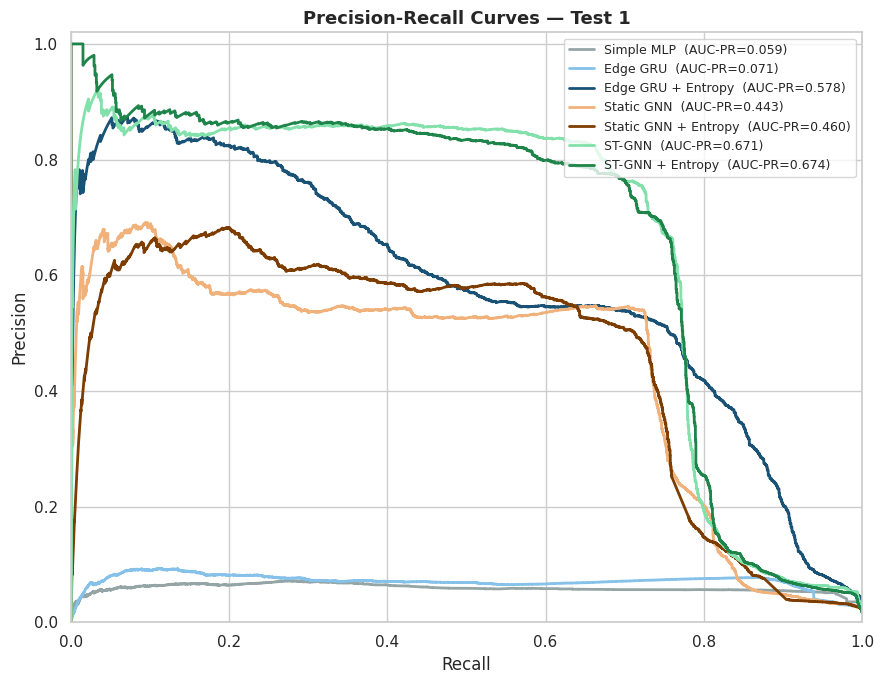

In [24]:
# ── Precision-Recall curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for display in MODEL_ORDER:
    if display not in pr_results:
        continue
    res = pr_results[display]
    prec, rec, _ = precision_recall_curve(res['y_true'], res['y_probs'])
    aucpr = auc(rec, prec)
    ax.plot(rec, prec, label=f"{display}  (AUC-PR={aucpr:.3f})",
            color=COLORS[display], linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Test 1', fontsize=13, weight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pr_curves_test1.png', dpi=300)
plt.show()

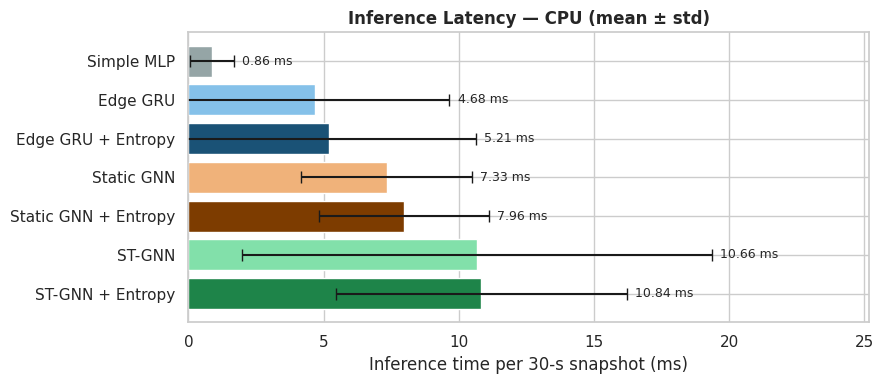


Latency table (mean ± std over 429 snapshots, CPU):


,Mean (ms),Std (ms)
Model,,
Simple MLP,0.8650,0.8150
Edge GRU,4.6850,4.9590
Edge GRU + Entropy,5.2110,5.4060
Static GNN,7.3250,3.1460
Static GNN + Entropy,7.9620,3.1490
ST-GNN,10.6570,8.6950
ST-GNN + Entropy,10.8370,5.3690


In [27]:
# ── Latency comparison chart ──────────────────────────────────────────────
lat_rows = [{'Model': k, 'mean_ms': v['mean_ms'], 'std_ms': v['std_ms'], 'n': v['n_snapshots']}
            for k, v in pr_results.items() if k in MODEL_ORDER]
df_lat = pd.DataFrame(lat_rows)
df_lat['Model'] = pd.Categorical(df_lat['Model'], categories=MODEL_ORDER, ordered=True)
df_lat = df_lat.sort_values('Model')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_lat['Model'], df_lat['mean_ms'],
               xerr=df_lat['std_ms'], capsize=4,
               color=[COLORS[m] for m in df_lat['Model']], edgecolor='white')
ax.bar_label(bars, labels=[f"{r:.2f} ms" for r in df_lat['mean_ms']],
             padding=6, fontsize=9)
ax.set_xlabel('Inference time per 30-s snapshot (ms)')
ax.set_title('Inference Latency — CPU (mean ± std)', fontsize=12, weight='bold')
ax.set_xlim(0, (df_lat['mean_ms'] + df_lat['std_ms']).max() * 1.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/latency_comparison.png', dpi=300)
plt.show()


n_ref = int(df_lat['n'].iloc[0])
print(f'\nLatency table (mean ± std over {n_ref} snapshots, CPU):')
df_display = df_lat.set_index('Model')[['mean_ms', 'std_ms']].rename(
    columns={'mean_ms': 'Mean (ms)', 'std_ms': 'Std (ms)'}
).round(3)
from IPython.display import display as ipy_display
ipy_display(df_display)
